In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

print("Datasets Loaded Successfully")
print(nav.head())

Datasets Loaded Successfully
   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692


In [3]:
print("NAV Dataset Shape:", nav.shape)

nav.info()

nav.describe()

NAV Dataset Shape: (46000, 3)
<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.5 MB


,amfi_code,nav
count,46000.000000,46000.000000
mean,120247.000000,269.570265
std,14352.317221,577.187060
min,100016.000000,26.136600
25%,118632.750000,69.170425
50%,119551.500000,122.732150
75%,120842.250000,260.338675
max,149324.000000,4268.549700


In [4]:
nav.isnull().sum()

amfi_code    0
date         0
nav          0
dtype: int64

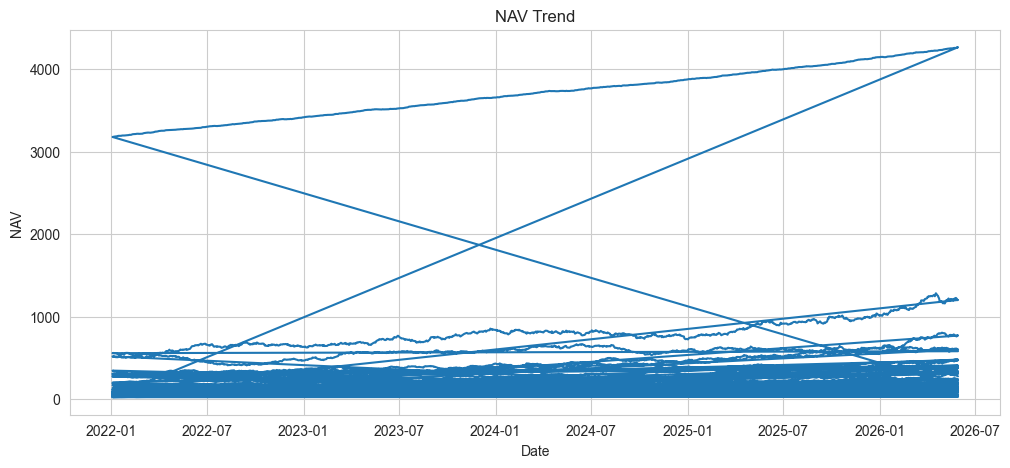

In [5]:
nav["date"] = pd.to_datetime(nav["date"])

plt.figure(figsize=(12,5))
plt.plot(nav["date"], nav["nav"])
plt.title("NAV Trend")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.show()

In [6]:
aum["year"] = pd.to_datetime(aum["date"]).dt.year

yearly_aum = aum.groupby("year")["aum"].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=yearly_aum, x="year", y="aum")

plt.title("Year-wise AUM Growth")
plt.xlabel("Year")
plt.ylabel("Total AUM")

plt.show()

KeyError: 'Column not found: aum'

In [7]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes',
       'year'],
      dtype='str')


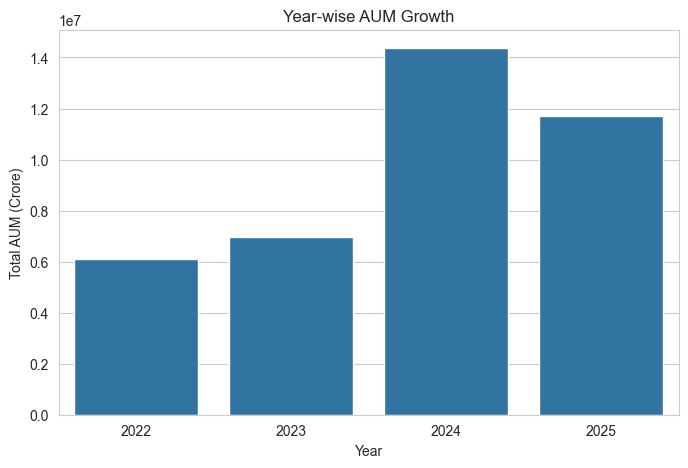

In [8]:
aum["year"] = pd.to_datetime(aum["date"]).dt.year

yearly_aum = aum.groupby("year")["aum_crore"].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=yearly_aum, x="year", y="aum_crore")

plt.title("Year-wise AUM Growth")
plt.xlabel("Year")
plt.ylabel("Total AUM (Crore)")

plt.show()

In [9]:
print(sip.columns)

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')


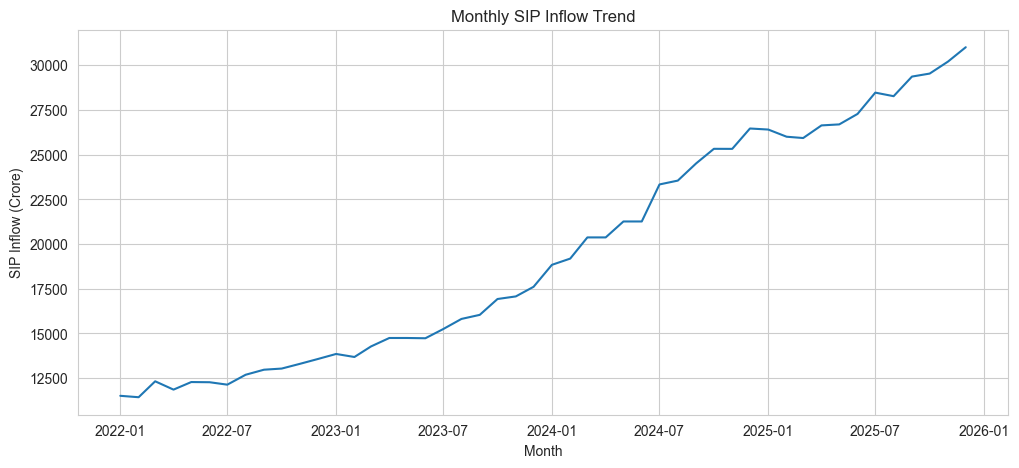

In [10]:
sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(12,5))
plt.plot(sip["month"], sip["sip_inflow_crore"])

plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.grid(True)

plt.show()

In [11]:
sip.describe()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
count,48,48.000000,48.000000,48.000000,48.000000,36.000000
mean,2023-12-16 11:00:00,19577.520833,7.189583,9.893750,8.632083,31.456944
min,2022-01-01 00:00:00,11438.000000,4.910000,7.500000,4.800000,15.800000
25%,2022-12-24 06:00:00,13658.500000,6.110000,8.775000,5.790000,20.245000
50%,2023-12-16 12:00:00,18224.000000,7.150000,9.200000,7.265000,28.295000
75%,2024-12-08 18:00:00,25944.250000,8.300000,9.562500,10.525000,40.807500
max,2025-12-01 00:00:00,31002.000000,9.350000,46.000000,15.900000,53.050000
std,NaN,6354.329621,1.271457,5.370745,3.613579,11.768190


In [12]:
max_sip = sip.loc[sip["sip_inflow_crore"].idxmax()]

print("Highest SIP Inflow Month")
print(max_sip)

Highest SIP Inflow Month
month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object


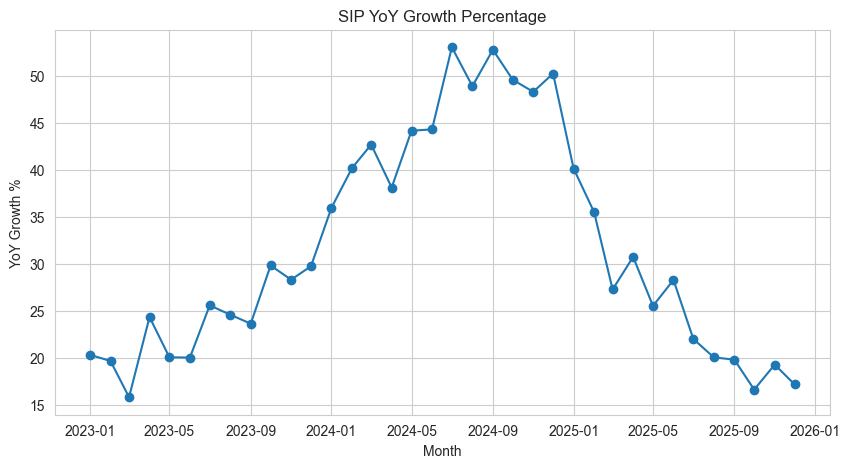

In [13]:
plt.figure(figsize=(10,5))

plt.plot(
    sip["month"],
    sip["yoy_growth_pct"],
    marker="o"
)

plt.title("SIP YoY Growth Percentage")
plt.xlabel("Month")
plt.ylabel("YoY Growth %")
plt.grid(True)

plt.show()

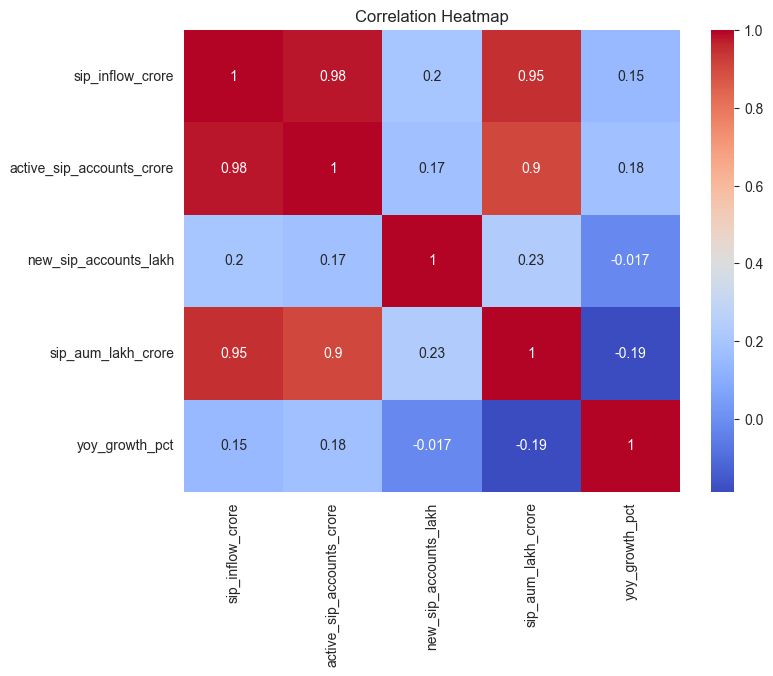

In [14]:
corr_data = sip.select_dtypes(include='number')

plt.figure(figsize=(8,6))
sns.heatmap(corr_data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Key Findings

1. NAV dataset contains 46,000 records with no missing values.

2. AUM showed significant growth from 2022 to 2024, indicating increasing investor participation.

3. SIP inflows increased steadily over time, showing strong retail investor confidence.

4. The highest SIP inflow was observed towards the end of 2025.

5. Dataset quality is good with minimal data issues after cleaning.

6. Mutual fund industry assets under management have expanded consistently during the analysis period.

7. SIP inflows and active SIP accounts show a very strong positive correlation (0.98).

8. SIP AUM is strongly correlated with SIP inflows (0.95), indicating asset growth is driven by consistent investments.